In [213]:
import os
import cv2
import time
import random
import keras_ocr
import numpy as np
import matplotlib.pyplot as plt

# keras-ocr

In [214]:
d = 'imgs'
images = os.listdir(d)
pipeline = keras_ocr.pipeline.Pipeline()

Looking for /home/greystone/.keras-ocr/craft_mlt_25k.h5
Looking for /home/greystone/.keras-ocr/crnn_kurapan.h5


6/6 [==============================] - 5s 645ms/step
comsumming time: 8.87 (s)


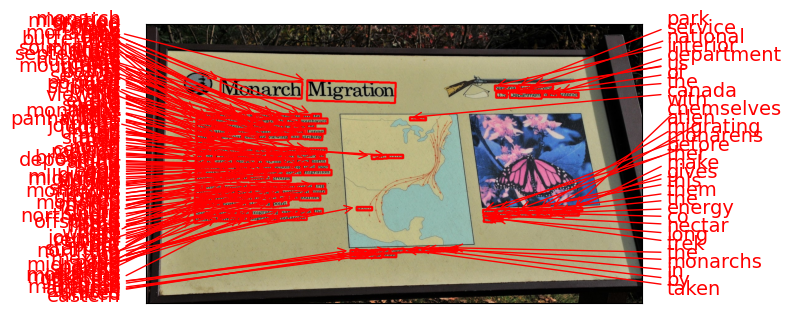

In [215]:
start = time.time()

# predict one image
img = random.choice(images)
img = d+"/"+img
imgs = [keras_ocr.tools.read(img)] # list input but one element
preds = pipeline.recognize(imgs)
# draw prediction
fig,ax = plt.subplots()
# plt.figure(figsize=(10,10))
keras_ocr.tools.drawAnnotations(image=imgs[0],predictions=preds[0],ax=ax)

duration = time.time() - start

print(f'comsumming time: {duration:.2f} (s)',flush=True)

# read image by imread

2/2 [==============================] - 1s 168ms/step
comsumming time: 5.55 (s)


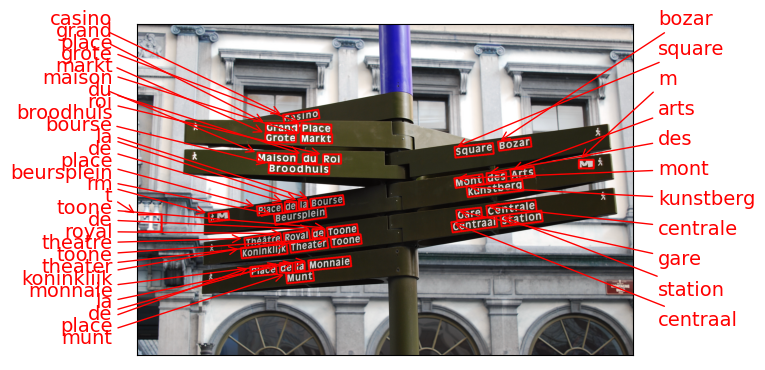

In [242]:
start = time.time()

# input as np array from cv2.imread
img = random.choice(images)
img = d+"/"+img
img = cv2.imread(img)
imgs = [img] # list input but one element
preds = pipeline.recognize(imgs)

# draw prediction
fig,ax = plt.subplots()

# plt.figure(figsize=(10,10))
keras_ocr.tools.drawAnnotations(image=imgs[0],predictions=preds[0],ax=ax)

duration = time.time() - start
print(f'comsumming time: {duration:.2f} (s)',flush=True)

In [243]:
texts = []
boxes = []

for text,box in preds[0]:
    texts.append(text)
    boxes.append(box)
    
print(len(texts))
print(len(boxes))

39
39


In [244]:
pts= boxes[0]
print(pts.shape)
print(pts)

(4, 2)
[[529.91425 329.89893]
 [657.5721  310.88602]
 [662.1223  341.43756]
 [534.4645  360.45047]]


In [245]:
# convert float to int
pts = np.int32(pts)
print(pts)
# reshape
pts = pts.reshape(-1,1,2) 
print(pts.shape)

[[529 329]
 [657 310]
 [662 341]
 [534 360]]
(4, 1, 2)


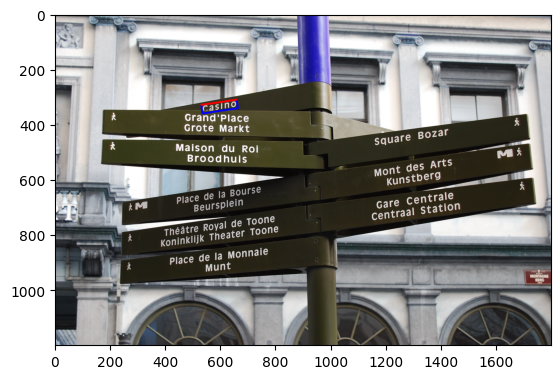

In [261]:
isClosed = True
 
# Blue color in BGR
color = (0, 0, 255)
 
# Line thickness of 2 px
thickness = 6

# font
font = cv2.FONT_HERSHEY_SIMPLEX

# fontScale
fontScale = 1

# start point and end point
start_point = pts[0][0]
end_point = pts[1][0]

# draw polygon
img = cv2.polylines(img,[pts],isClosed, color, thickness) # pts->4 point, [pts]->rec

# draw shape
img = cv2.line(img,start_point, end_point, (255,0,0), thickness)

# put text
#img = cv2.putText(img,texts[0],start_point,font,fontScale,color,4,cv2.LINE_AA)

plt.imshow(img)

In [308]:
np.arctan(start_point - end_point)*180/np.pi

array([-89.55238583,  86.9872125 ])

In [309]:
angle = np.arctan(start_point - end_point)[-1]*180/np.pi
print(int(angle))

86


In [310]:
print(tuple(start_point))

(529, 329)


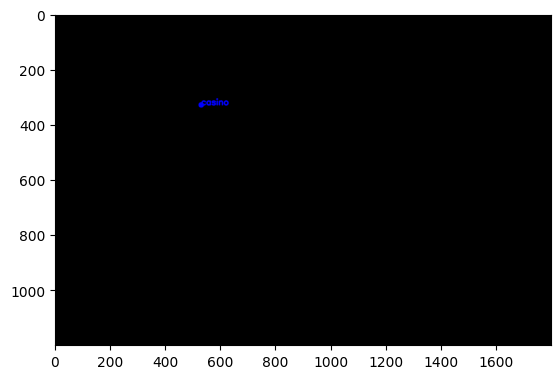

In [311]:
blank = np.zeros_like(img)
blank = cv2.putText(blank,texts[0],start_point,font,fontScale,color,4,cv2.LINE_AA)
blank = cv2.circle(blank,start_point, radius=10, color=(0, 0, 255), thickness=-1)
plt.imshow(blank)

In [312]:
blank.shape
height = blank.shape[0]
width = blank.shape[1]
center = (int(height/2),int(width/2))

In [317]:
M = cv2.getRotationMatrix2D(center,int(angle-90),1)
M

array([[  0.99862953,  -0.05233596,  47.92463977],
       [  0.05233596,   0.99862953, -30.16815502]])

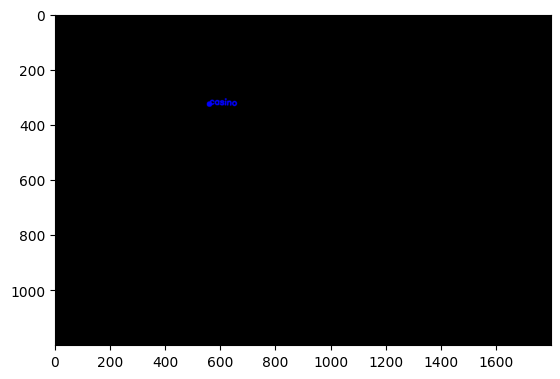

In [318]:
out = cv2.warpAffine(blank,M,(blank.shape[1],blank.shape[0]))
plt.imshow(out)

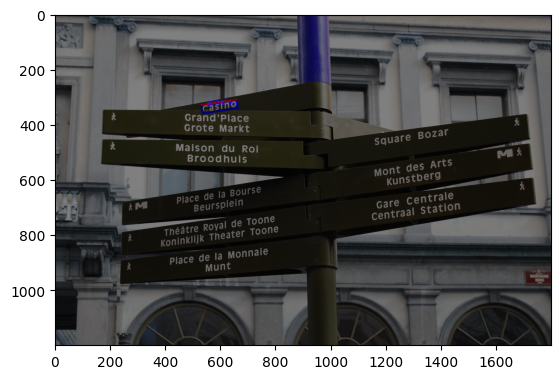

In [319]:
alpha = 0.5
img_out[:,:,:] = alpha * img[:,:,:] + (1-alpha) * out[:,:,:]
plt.imshow(img_out)

# draw image

In [332]:
# Blue color in BGR
color = (0, 0, 255)
# Line thickness of 2 px
thickness = 6
# font
font = cv2.FONT_HERSHEY_SIMPLEX
# fontScale
fontScale = 1
#
d = 'devices'
images = os.listdir(d)
pipeline = keras_ocr.pipeline.Pipeline()

Looking for /home/greystone/.keras-ocr/craft_mlt_25k.h5
Looking for /home/greystone/.keras-ocr/crnn_kurapan.h5


1/1 [==============================] - 1s 603ms/step
comsumming time: 5.64 (s)


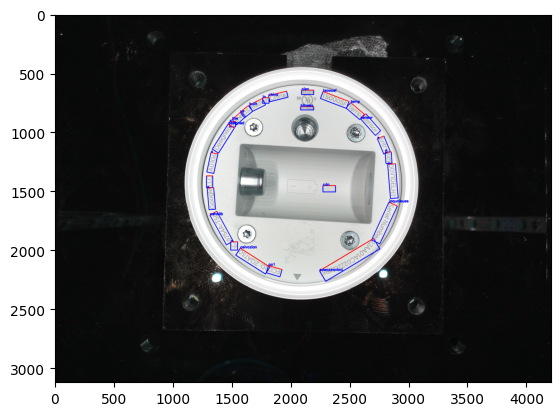

In [335]:
start = time.time()

# input as np array from cv2.imread
img = random.choice(images)
img = d+"/"+img
img = cv2.imread(img)
imgs = [img] # list input but one element
preds = pipeline.recognize(imgs)

# plt.figure(figsize=(10,10))
keras_ocr.tools.drawAnnotations(image=imgs[0],predictions=preds[0],ax=ax)

texts = []
boxes = []

for text,box in preds[0]:
    texts.append(text)
    boxes.append(box)
    
for i in range(len(texts)):
    # convert float to int
    pts = np.int32(boxes[i])
    # reshape
    pts = pts.reshape(-1,1,2) 
    isClosed = True
 
    # start point and end point
    start_point = pts[0][0]
    end_point = pts[1][0]

    # draw polygon
    img = cv2.polylines(img,[pts],isClosed, color, thickness) # pts->4 point, [pts]->rec

    # draw shape
    img = cv2.line(img,start_point, end_point, (255,0,0), thickness)

    # put text
    img = cv2.putText(img,texts[i],start_point,font,fontScale,color,4,cv2.LINE_AA)

# display
plt.imshow(img)

# save image
cv2.imwrite('pred.jpg',img)

duration = time.time() - start
print(f'comsumming time: {duration:.2f} (s)',flush=True)